## Computer Vision - Aufgabe 3: Image Stitching

### Einlesen der Bilder

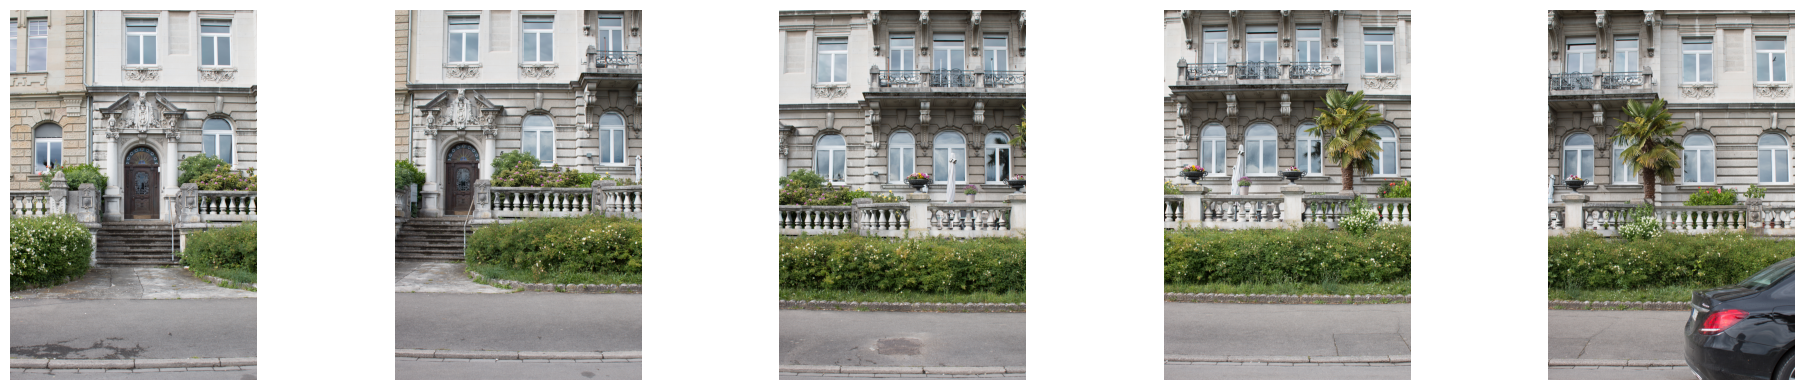

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data
from pathlib import Path

setname = "Set1"
images = []

for file in Path("Bilder").glob(f"{setname}*"):
    image = plt.imread(file)
    image = image.astype(float)
    image = image / 255
    images.append(image)
image1 = images[0]
image2 = images[1]

In [40]:
world = {

    # Tür
    "door_bottom":      [0, 1000],
    "door_middle":      [0, 500],
    "door_top":         [0, 0],

    # Pfosten
    "left_post":        [-800, 1000],
    "right_post":       [800, 1000],

    # Fenster 1
    "window1":          [1200, -200],

    # Fenster 2
    "window2":          [2200, -200],

    # Strom Fenster
    "power_window":     [1800, 200],

    # Fenster 3
    "window3":          [3200, -200],

    # Fenster 4
    "window4":          [4200, -200],

    # Deko
    "deco":             [3500, 300],

    # Fenster 5
    "window5":          [5200, -200],

    # Fenster 5 right edge
    "window5_edge":     [5700, 200],

    # Fenster 6
    "window6":          [6500, -200],

    # Fenster 6 bottom-right edge
    "window6_edge":     [7000, 400]
}

PAN_WIDTH = 7000
PAN_HEIGHT = 1000

bi1 = np.array([
    [1959, 3117],  # Tür unten
    [1959, 2583],  # Tür mitte
    [1951, 2011],  # Tür oben
    [2800, 3122],  # Rechter Pfosten
    [992, 3122],   # Linker Pfosten
    [3065, 1817]   # Fenster 1
], dtype=float)

oi1 = np.array([
    [0, 1000],
    [0, 500],
    [0, 0],
    [800, 1000],
    [-800, 1000],
    [1200, -200]
], dtype=float)
bi2 = np.array([
    [1428, 3064],  # Rechter Pfosten
    [2116, 1767],  # Fenster 1
    [1015, 1970],  # Tür oben
    [3205, 1747],  # Fenster 2
    [2863, 2115]   # Strom Fenster
], dtype=float)

oi2 = np.array([
    [800, 1000],
    [1200, -200],
    [0, 0],
    [2200, -200],
    [1800, 200]
], dtype=float)
bi3 = np.array([
    [1811, 2021],  # Fenster 2
    [1428, 2388],  # Strom Fenster
    [2522, 2025],  # Fenster 3
    [3226, 2029],  # Fenster 4
    [2149, 2132]   # Deko
], dtype=float)

oi3 = np.array([
    [2200, -200],
    [1800, 200],
    [3200, -200],
    [4200, -200],
    [3500, 300]
], dtype=float)
bi4 = np.array([
    [1435, 1908],  # Fenster 3
    [2142, 1899],  # Fenster 4
    [1035, 2020],  # Deko
    [3202, 1929],  # Fenster 5
    [3585, 2470]   # Fenster 5 edge
], dtype=float)

oi4 = np.array([
    [3200, -200],
    [4200, -200],
    [3500, 300],
    [5200, -200],
    [5700, 200]
], dtype=float)
bi5 = np.array([
    [2572, 2588],  # Fenster 5 edge
    [2222, 2052],  # Fenster 5
    [3330, 2049],  # Fenster 6
    [3587, 2582]   # Fenster 6 edge
], dtype=float)

oi5 = np.array([
    [5700, 200],
    [5200, -200],
    [6500, -200],
    [7000, 400]
], dtype=float)


### Bestimmung der Passpunkte pro Bild

Anmerkung: Bildkoordinaten von bspw. der Haustür ändern sich von Bild zu Bild, die Weltkoordinaten bleiben für die Haustür hingegen identisch!

Selbstdefinierter Ursprung: Unten links an der Hauswand

In [30]:
'''Bild 1:
1959, 3117 # Mitte Tür unten
1959, 2583 # Mitte Tür
1951, 2011 # Mitte Tür oben ---- Überlappung
2800, 3122 # Rechter Pfosten links ---- Überlappung
992, 3122 # Linker Pfosten links
3065, 1817 # Mitte Fenster ---- Überlappung

Bild 2:
1428, 3064 # Rechter Pfosten links ---- Überlappung
2116, 1767 # Mitte Fenster ---- Überlappung
1015, 1970 # Mitte Tür oben ---- Überlappung
3205, 1747 # Fenster 2 mitte ---- Überlappung 2
2863, 2115 # Strom Fenster ---- Überlappung 2

Bild 3:
1811, 2021 # Fenster 2 mitte ---- Überlappung 2
1428, 2388 # Strom Fenster ---- Überlappung 2
2522, 2025 # Fenster 3 Mitte ---- Überlappung 3
3226, 2029 # Fenster 4 Mitte ---- Überlappung 3
2149, 2132 # Mitte Deko ---- Überlappung 3

Bild 4:
1435, 1908 # Fenster 3 Mitte ---- Überlappung 3
2142, 1899 # Fenster 4 Mitte ---- Überlappung 3
1035, 2020 # Mitte Deko ---- Überlappung 3
3202, 1929 # Fenster 5 Mitte ---- Überlappung 4
3585, 2470 # Kante rechts Fenster 5 ---- Überlappung 4

Bild 5:
2572, 2588 # Kante rechts Fenster 5 ---- Überlappung 4
2222, 2052 # Fenster 5 Mitte ---- Überlappung 4
3330, 2049 # Fenster 6 Mitte
3587, 2582 # Fenster 6 rahmenkante unten rechts'''

'Bild 1:\n1959, 3117 # Mitte Tür unten\n1959, 2583 # Mitte Tür\n1951, 2011 # Mitte Tür oben ---- Überlappung\n2800, 3122 # Rechter Pfosten links ---- Überlappung\n992, 3122 # Linker Pfosten links\n3065, 1817 # Mitte Fenster ---- Überlappung\n\nBild 2:\n1428, 3064 # Rechter Pfosten links ---- Überlappung\n2116, 1767 # Mitte Fenster ---- Überlappung\n1015, 1970 # Mitte Tür oben ---- Überlappung\n3205, 1747 # Fenster 2 mitte ---- Überlappung 2\n2863, 2115 # Strom Fenster ---- Überlappung 2\n\nBild 3:\n1811, 2021 # Fenster 2 mitte ---- Überlappung 2\n1428, 2388 # Strom Fenster ---- Überlappung 2\n2522, 2025 # Fenster 3 Mitte ---- Überlappung 3\n3226, 2029 # Fenster 4 Mitte ---- Überlappung 3\n2149, 2132 # Mitte Deko ---- Überlappung 3\n\nBild 4:\n1435, 1908 # Fenster 3 Mitte ---- Überlappung 3\n2142, 1899 # Fenster 4 Mitte ---- Überlappung 3\n1035, 2020 # Mitte Deko ---- Überlappung 3\n3202, 1929 # Fenster 5 Mitte ---- Überlappung 4\n3585, 2470 # Kante rechts Fenster 5 ---- Überlappung 4\n

### Ermittlung der Kameraparameter _a_ für die projektive Entzerrung

In [41]:
def compute_rectification(bi, oi):
    A = []
    for i in range(len(oi)):
        x, y = bi[i]
        u, v = oi[i]
        A.append([x, y, 1, 0, 0, 0, -(u*x), -(u*y)])
        A.append([0, 0, 0, x, y, 1, -(v*x), -(v*y)])
    A = np.array(A)

    x = oi.flatten()
    h = np.linalg.pinv(A) @ x

    return h
H1 = compute_rectification(bi1, oi1)
H2 = compute_rectification(bi2, oi2)
print(H1)

[ 8.74430115e-01 -2.21023717e-02 -1.64462870e+03 -5.05510541e-02
  8.49350400e-01 -1.58827914e+03 -7.10677768e-05  3.47672835e-05]


(-0.5, 6999.5, 999.5, -0.5)

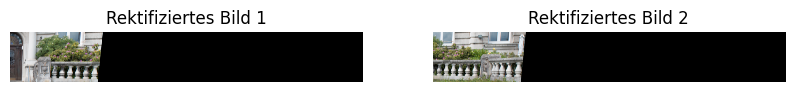

In [42]:
def compute_weights(height, width):
    weights = np.zeros((height, width))
    for i in range(height):
        for j in range(width):
            w1 = 1 - (2/width) * abs(j - width/2)
            w2 = 1 - (2/height) * abs(i - height/2)
            weights[i, j] = w1 * w2
    return weights

a1 = H1[0]
a2 = H1[1]
a3 = H1[2]
b1 = H1[3]
b2 = H1[4]
b3 = H1[5]
c1 = H1[6]
c2 = H1[7]
a11 = H2[0]
a22 = H2[1]
a33 = H2[2]
b11 = H2[3]
b22 = H2[4]
b33 = H2[5]
c11 = H2[6]
c22 = H2[7]
def image_rectification(image, out_h, out_w):
    rectified_image = np.zeros((out_h, out_w, 3), dtype=image.dtype)

    for i in range(out_h):
        for j in range(out_w):
            x_ref = j
            y_ref = i
            x = ((b2 - c2*b3)*x_ref + (a3*c2- a2)*y_ref + a2*b3 - a3*b2) / ((b1*c2 - b2*c1)*x_ref + (a2*c1 - a1*c2)*y_ref + a1*b2 - a2*b1)
            y = ((b3*c1 - b1)*x_ref + (a1 - a3*c1)*y_ref + a3*b1 - a1*b3) / ((b1*c2 - b2*c1)*x_ref + (a2*c1 - a1*c2)*y_ref + a1*b2 - a2*b1)
            x_n = int(np.round(x))
            y_n = int(np.round(y))
            if 0 <= x_n < image.shape[1] and 0 <= y_n < image.shape[0]:
                rectified_image[i, j] = image[y_n, x_n]
            else:
                rectified_image[i, j] = 0
    return rectified_image
rectified_image1 = image_rectification(image1, PAN_HEIGHT, PAN_WIDTH)
rectified_image2 = image_rectification(image2, PAN_HEIGHT, PAN_WIDTH)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(rectified_image1)
plt.title("Rektifiziertes Bild 1")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(rectified_image2)
plt.title("Rektifiziertes Bild 2")
plt.axis('off')


Text(0.5, 1.0, 'Blended Image')

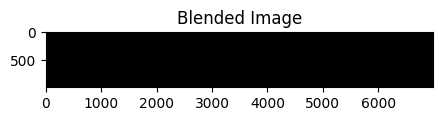

In [45]:
def blend_images(img1, img2, mode="average"):

    h, w = img1.shape[:2]

    weights1 = compute_weights(h, w)
    weights2 = compute_weights(h, w)

    output = np.zeros_like(img1, dtype=np.float32)

    for y in range(h):
        for x in range(w):

            p1 = img1[y, x].astype(np.float32)
            p2 = img2[y, x].astype(np.float32)

            w1 = weights1[y, x]
            w2 = weights2[y, x]

            valid1 = np.any(p1 > 0)
            valid2 = np.any(p2 > 0)

            if valid1 and not valid2:
                output[y, x] = p1

            elif valid2 and not valid1:
                output[y, x] = p2

            elif valid1 and valid2:

                if mode == "max":
                    if w1 > w2:
                        output[y, x] = p1
                    else:
                        output[y, x] = p2

                elif mode == "average":
                    output[y, x] = (w1*p1 + w2*p2) / (w1 + w2)

    return output.astype(np.uint8)
blended_image = blend_images(rectified_image1, rectified_image2, mode="max")
plt.figure(figsize=(5, 5))
plt.imshow(blended_image)
plt.title("Blended Image")

Text(0.5, 1.0, 'Panorama Image')

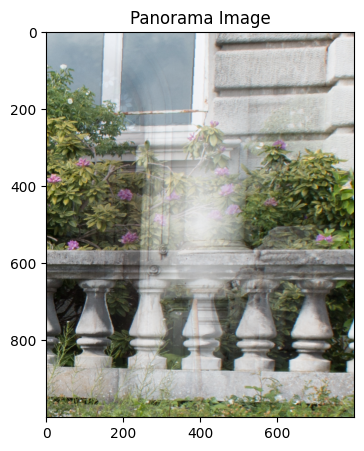